# Train DeepONet on Fluent cell-center subdomains

This notebook uses the non-grid dataset. The trunk queries are original Fluent cell centers inside each subdomain, not a 256×256 raster grid. Branch sensors are exterior BC points plus interpolated interface points.

In [ ]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import builtins
import json
import sys
import logging
import subprocess
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from datetime import datetime

MODULE_DIR = Path.cwd()
if not (MODULE_DIR / "fluent_deeponet.py").exists():
    MODULE_DIR = MODULE_DIR / "DeepONet"
ROOT_DIR = MODULE_DIR.parent

if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

from deeponet_fluent_dataset import (
    build_fluent_deeponet_dataset,
    DeepONetCellDataset,
    deeponet_cell_collate_fn,
)

from fluent_deeponet import (
    FeatureNormalizer,
    DeepONet,
    train_deeponet_one_epoch,
    evaluate_deeponet,
)

from plot import (
    plot_prediction_imshow_from_points,
    collect_predictions_for_data,
)

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
rng = np.random.default_rng(SEED)
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

In [ ]:
comment = "multi-AR geometry encoding (Re + SDF): train AR5+AR16+50xAR10, test AR8 interp / AR4+AR20 extrap"

# Set to an existing run dir name (e.g. "transient_080526_1") or Path to resume
# logging/checkpointing there. Leave as None to create a new dated run directory.
RESUME_DIR = None

In [ ]:
def save_git_snapshot(run_dir):
    run_dir = Path(run_dir)
    run_dir.mkdir(parents=True, exist_ok=True)

    commands = {
        "git_commit.txt": ["git", "rev-parse", "HEAD"],
        "git_status.txt": ["git", "status"],
        "git_diff.patch": ["git", "diff"],
        "git_diff_cached.patch": ["git", "diff", "--cached"],
    }

    for filename, command in commands.items():
        with open(run_dir / filename, "w", encoding="utf-8") as f:
            subprocess.run(command, stdout=f, stderr=subprocess.STDOUT)

output_root = MODULE_DIR / "results"
output_root.mkdir(parents=True, exist_ok=True)

if RESUME_DIR is not None:
    output_dir = Path(RESUME_DIR)
    if not output_dir.is_absolute():
        output_dir = output_root / output_dir
    output_dir = output_dir.resolve()
    output_dir.mkdir(parents=True, exist_ok=True)
else:
    today = datetime.now().strftime("%m%d%y")
    run_no = len([s for s in output_root.iterdir() if s.name.startswith(f"{today}_")]) + 1
    output_str = f"{today}_{run_no}"
    output_dir = output_root / output_str
    output_dir.mkdir(parents=True, exist_ok=True)

save_git_snapshot(output_dir / "code_snapshot")

logger = logging.getLogger("deeponet")
logging.basicConfig(
    filename=output_dir / "training.log",
    level=logging.INFO,
    force=True,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)

if not hasattr(builtins, "_orig_print"):
    builtins._orig_print = builtins.print
orig_print = builtins._orig_print
def print(*args, sep=" ", end="\n", file=None, flush=False):
    orig_print(*args, sep=sep, end=end, file=file, flush=flush)
    logger.info(sep.join(map(str, args)))

print("Training comment")
print(comment)
print("Output directory:", output_dir)
if RESUME_DIR is not None:
    print("Resuming into existing directory:", output_dir)

## Case file paths

In [ ]:
ROOT_DIR = Path("/home/hantianl/Documents/PIDIF/")

# Case pool: all 200 channel_water (AR10, H=0.1mm) plus the multi-AR block of
# channel_water_ablation (2026-08-18 renumbering). All channels are 1mm long,
# Uin = 1 m/s, so Re = U*H/nu differs per group:
#   200-209 AR4  H0.25   | 210-259 AR5  H0.2  | 260-269 AR8 H0.125
#   270-319 AR16 H0.0625 | 320-329 AR20 H0.05
CASE_DATASET = {}
CASE_DATASET.update({
    ch.name: "channel_water"
    for ch in (ROOT_DIR / "runs_2d" / "channel_water").iterdir()
    if ch.name.startswith("channel_")
})
CASE_DATASET.update({f"channel_{i:03d}": "channel_water_ablation" for i in range(200, 330)})

def case_paths(ch):
    ds = CASE_DATASET[ch]
    return {
        "design": ROOT_DIR / f"2d_geometry_specs/{ds}/{ch}.json",
        "mesh": ROOT_DIR / f"runs_2d/{ds}/{ch}/{ch}.msh.h5",
        "dat": ROOT_DIR / f"runs_2d/{ds}/{ch}/case2d.dat.h5",
    }

# Keep only cases whose design/mesh/dat files all exist (completed runs).
available_cases = [
    ch for ch in CASE_DATASET
    if all(case_paths(ch)[k].exists() for k in ("design", "mesh", "dat"))
]
case_files = {ch: case_paths(ch) for ch in available_cases}

n_water = sum(1 for ch in available_cases if CASE_DATASET[ch] == "channel_water")
n_abl = len(available_cases) - n_water
print(f"Available cases: {len(available_cases)} ({n_water} channel_water + {n_abl} multi-AR)")

# Training config

In [ ]:
# Split design:
#   train/validation (45 train / 5 val per group):
#     AR5  H0.20   channel_210-259          (50)
#     AR16 H0.0625 channel_270-319          (50)
#     AR10 H0.10   50 of the 200 channel_water cases
#   test:
#     ar10_shapes: remaining 150 channel_water (unseen shapes, in-range AR)
#     ar8_interp:  channel_260-269  (AR interpolation)
#     ar4_extrap:  channel_200-209  (AR extrapolation, low)
#     ar20_extrap: channel_320-329  (AR extrapolation, high)
SPLIT_SEED = 0
_split_rng = np.random.default_rng(SPLIT_SEED)

_case_num = lambda c: int(c.split("_")[-1])
water_all = sorted((ch for ch in available_cases if CASE_DATASET[ch] == "channel_water"), key=_case_num)
_water_shuffled = list(water_all)
_split_rng.shuffle(_water_shuffled)

TRAINVAL_GROUPS = {
    "AR5":  [f"channel_{i:03d}" for i in range(210, 260)],
    "AR16": [f"channel_{i:03d}" for i in range(270, 320)],
    "AR10": sorted(_water_shuffled[:50], key=_case_num),
}

N_VAL_PER_GROUP = 5
TRAIN_CASES, VALID_CASES = [], []
for group_name, group_cases in TRAINVAL_GROUPS.items():
    cases = [ch for ch in group_cases if ch in case_files]
    if len(cases) != len(group_cases):
        missing = sorted(set(group_cases) - set(cases))
        print(f"WARNING: {group_name} is missing solved cases: {missing}")
    shuffled = list(cases)
    _split_rng.shuffle(shuffled)
    VALID_CASES += shuffled[:N_VAL_PER_GROUP]
    TRAIN_CASES += shuffled[N_VAL_PER_GROUP:]
    print(f"{group_name}: {len(shuffled) - N_VAL_PER_GROUP} train, valid={sorted(shuffled[:N_VAL_PER_GROUP], key=_case_num)}")

TEST_SETS = {
    "ar10_shapes": sorted(_water_shuffled[50:], key=_case_num),
    "ar8_interp":  [f"channel_{i:03d}" for i in range(260, 270)],
    "ar4_extrap":  [f"channel_{i:03d}" for i in range(200, 210)],
    "ar20_extrap": [f"channel_{i:03d}" for i in range(320, 330)],
}
TEST_CASES = [ch for cases in TEST_SETS.values() for ch in cases]

print(f"\nTrain cases: {len(TRAIN_CASES)} | Valid cases: {len(VALID_CASES)}")
for name, cases in TEST_SETS.items():
    print(f"Test [{name}]: {len(cases)}")

# Interfaces at fixed locations; n_sub adapts to each channel's aspect ratio.
N_SUBDOMAINS = "adaptive"
N_INTERFACE_POINTS = 256
N_WALL_POINTS = 256
INTERFACE_PLACEMENT = "random"
INTERFACE_JITTER = 0.0
MIN_SUBDOMAIN_WIDTH = 0.01
N_REALIZATIONS_TRAIN = 10
HORIZONTAL_INTERFACE = False
HORIZONTAL_INTERFACE_JITTER = 0.01

# Geometry-encoding channels: per-case log10(Re) in the branch, and the wall-SDF
# as an extra branch channel + third trunk input (Geom-DeepONet style).
INCLUDE_REYNOLDS = True
INCLUDE_SDF = True

N_QUERY_TRAIN = None
N_QUERY_VALID = None
BATCH_SIZE = 30

# Isothermal runs have no temperature field: train on pressure/u/v only.
FIELD_MAP = {"pressure": "SV_P", "u": "SV_U", "v": "SV_V"}

LAMBDA_BC = 1.0
LAMBDA_PDE = 0
N_PDE_POINTS = 10000  # Random interior/cell-center collocation points per sample.
PDE_RESIDUAL_WEIGHTS = {
    "continuity": 1.0,
    "x_momentum": 1.0,
    "y_momentum": 1.0,
}
WATER_DENSITY = 998.2  # kg/m^3
WATER_KINEMATIC_VISCOSITY = 1.003e-3 / WATER_DENSITY  # m^2/s

bc_kwargs = {
    "inlet_v": 0.0,
    "outlet_p": 0.0,
    "wall_u": 0.0,
    "wall_v": 0.0,
}

## Build non-grid training/validation dataset

In [ ]:
train_data = build_fluent_deeponet_dataset(
    case_files=case_files,
    case_ids=TRAIN_CASES,
    n_subdomains=N_SUBDOMAINS,
    n_interface_points=N_INTERFACE_POINTS,
    n_boundary_points=N_WALL_POINTS,
    n_realizations=N_REALIZATIONS_TRAIN,
    interface_placement=INTERFACE_PLACEMENT,
    interface_jitter=INTERFACE_JITTER,
    min_subdomain_width=MIN_SUBDOMAIN_WIDTH,
    horizontal_interface=HORIZONTAL_INTERFACE,
    insert_sharp_control_point_interfaces=False,
    field_map=FIELD_MAP,
    bc_kwargs=bc_kwargs,
    keep_raw_case_data=False,
    rng=rng,
    include_reynolds=INCLUDE_REYNOLDS,
    include_sdf=INCLUDE_SDF,
    kinematic_viscosity=WATER_KINEMATIC_VISCOSITY,
)

valid_data = build_fluent_deeponet_dataset(
    case_files=case_files,
    case_ids=VALID_CASES,
    n_subdomains=N_SUBDOMAINS,
    n_interface_points=N_INTERFACE_POINTS,
    n_boundary_points=N_WALL_POINTS,
    interface_placement=INTERFACE_PLACEMENT,
    interface_jitter=0,
    min_subdomain_width=MIN_SUBDOMAIN_WIDTH,
    horizontal_interface=HORIZONTAL_INTERFACE,
    insert_sharp_control_point_interfaces=False,
    field_map=FIELD_MAP,
    bc_kwargs=bc_kwargs,
    keep_raw_case_data=False,
    rng=rng,
    include_reynolds=INCLUDE_REYNOLDS,
    include_sdf=INCLUDE_SDF,
    kinematic_viscosity=WATER_KINEMATIC_VISCOSITY,
)

samples = train_data["samples"]
metadata = train_data["metadata"]
branch_channel_names = list(train_data["branch_channel_names"])
trunk_channel_names = list(train_data["trunk_channel_names"])
output_channel_names = list(train_data["output_channel_names"])

ars = np.asarray([int(round(m["aspect_ratio"])) for m in metadata], dtype=np.int64)
subdomain_ids = np.asarray([int(m["subdomain_id"]) for m in metadata], dtype=np.int64)
local_aspect_ratios = np.asarray([float(m["local_aspect_ratio"]) for m in metadata], dtype=np.float32)
n_cells = np.asarray([int(m["n_cells"]) for m in metadata], dtype=np.int64)

print("Train samples:", len(train_data["samples"]))
print("Valid samples:", len(valid_data["samples"]))

print("Train branch channels:", train_data["branch_channel_names"])
print("Train trunk channels:", train_data["trunk_channel_names"])
print("Output channels:", train_data["output_channel_names"])

if INCLUDE_REYNOLDS:
    _train_res = sorted({round(10.0 ** float(m["log10_reynolds"]), 1) for m in metadata})
    print("Train Reynolds numbers:", _train_res)

print("Example train sample:")
print("branch:", train_data["samples"][0]["branch"].shape)
print("query:", train_data["samples"][0]["query"].shape)
print("target:", train_data["samples"][0]["target"].shape)

In [ ]:
train_metadata = train_data["metadata"]
valid_metadata = valid_data["metadata"]

train_subdomain_ids = np.asarray(
    [m["subdomain_id"] for m in train_metadata],
    dtype=np.int64,
)

valid_subdomain_ids = np.asarray(
    [m["subdomain_id"] for m in valid_metadata],
    dtype=np.int64,
)

train_case_ids = sorted({int(m["case_id"].split("_")[-1]) for m in train_metadata})
valid_case_ids = sorted({int(m["case_id"].split("_")[-1]) for m in valid_metadata})

print("Train cases:", train_case_ids)
print("Valid cases:", valid_case_ids)

In [ ]:
def concatenate_targets(data):
    return np.concatenate(
        [sample["target"] for sample in data["samples"]],
        axis=0,
    ).astype(np.float32)


train_targets_all = concatenate_targets(train_data)

y_normalizer = FeatureNormalizer(train_targets_all)

print("Y mean:", y_normalizer.mean)
print("Y std:", y_normalizer.std)

train_local_aspects = np.asarray(
    [m["local_aspect_ratio"] for m in train_data["metadata"]],
    dtype=np.float32,
)

local_aspect_mean = float(train_local_aspects.mean())
local_aspect_std = float(train_local_aspects.std() + 1.0e-6)

print("local_aspect_mean:", local_aspect_mean)
print("local_aspect_std:", local_aspect_std)

# log10(Re) is passed through UN-standardized (log_re stats = None): the raw
# values are already O(1) (log10 of 50/100/200 = 1.7/2.0/2.3) and every branch
# consumer (plot.py, eval physics inference) then normalizes consistently
# without extra plumbing.
log_re_mean = None
log_re_std = None
if INCLUDE_REYNOLDS:
    train_log_re = np.asarray(
        [m["log10_reynolds"] for m in train_data["metadata"]], dtype=np.float32
    )
    print("train log10(Re) values:", sorted(set(np.round(train_log_re, 4).tolist())))

# Per-sample physical scales for the nondimensional steady NS residual.
# Dataset metadata lengths are in mm; the PDE helper expects metres.
_case_velocity = {}
for case_id in TRAIN_CASES:
    with open(case_files[case_id]["design"], "r", encoding="utf-8") as f:
        _case_velocity[case_id] = float(json.load(f)["metadata"]["Uin_mps"])

pde_physics = {
    "density": WATER_DENSITY,
    "kinematic_viscosity": WATER_KINEMATIC_VISCOSITY,
    "x_length": np.asarray(
        [(m["x_right_mm"] - m["x_left_mm"]) * 1.0e-3 for m in train_data["metadata"]],
        dtype=np.float32,
    ),
    "y_length": np.asarray(
        [(m["y_top_mm"] - m["y_bottom_mm"]) * 1.0e-3 for m in train_data["metadata"]],
        dtype=np.float32,
    ),
    "velocity_scale": np.asarray(
        [_case_velocity[m["case_id"]] for m in train_data["metadata"]],
        dtype=np.float32,
    ),
}

print("PDE Reynolds-number range:",
      float(np.min(pde_physics["velocity_scale"] * pde_physics["x_length"] / WATER_KINEMATIC_VISCOSITY)),
      float(np.max(pde_physics["velocity_scale"] * pde_physics["x_length"] / WATER_KINEMATIC_VISCOSITY)))

## DataLoaders

In [ ]:
train_ds = DeepONetCellDataset(
    samples=train_data["samples"],
    sample_indices=None,
    n_query_points=N_QUERY_TRAIN,
    random_query=True,
    target_y_normalizer=y_normalizer,
    local_aspect_mean=local_aspect_mean,
    local_aspect_std=local_aspect_std,
    branch_channel_names=train_data["branch_channel_names"],
    log_re_mean=log_re_mean,
    log_re_std=log_re_std,
)

valid_ds = DeepONetCellDataset(
    samples=valid_data["samples"],
    sample_indices=None,
    n_query_points=N_QUERY_VALID,
    random_query=False,
    target_y_normalizer=y_normalizer,
    local_aspect_mean=local_aspect_mean,
    local_aspect_std=local_aspect_std,
    branch_channel_names=valid_data["branch_channel_names"],
    log_re_mean=log_re_mean,
    log_re_std=log_re_std,
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
    collate_fn=deeponet_cell_collate_fn,
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    collate_fn=deeponet_cell_collate_fn,
)

branch_batch, query_batch, target_batch, query_batch_id, sample_idx_batch, branch_mask_batch = next(iter(train_loader))

print("branch batch:", branch_batch.shape)
print("query batch:", query_batch.shape)
print("target batch:", target_batch.shape)
print("query batch id:", query_batch_id.min(), query_batch_id.max())
print("sample indices:", sample_idx_batch)
print("branch mask batch:", branch_mask_batch.shape)


## Model

In [ ]:
branch_input_dim = train_data["samples"][0]["branch"].shape[-1]
trunk_input_dim = train_data["samples"][0]["query"].shape[-1]
output_channels = train_data["samples"][0]["target"].shape[-1]

# Geom-DeepONet ablation switches (keep gelu / no mixing for the baseline run).
TRUNK_ACTIVATION = "gelu"      # "siren" for the SIREN-trunk variant
BRANCH_TRUNK_MIXING = False    # True for the einsum branch-trunk mixing variant

model = DeepONet(
    branch_input_dim=branch_input_dim,
    trunk_input_dim=trunk_input_dim,
    output_channels=output_channels,
    latent_dim=128,
    branch_point_hidden_dim=128,
    branch_point_depth=3,
    branch_global_hidden_dim=128,
    branch_global_depth=3,
    trunk_hidden_dim=128,
    trunk_depth=4,
    aggregation="mean",
    activation="gelu",
    layer_norm=False,
    trunk_activation=TRUNK_ACTIVATION,
    branch_trunk_mixing=BRANCH_TRUNK_MIXING,
).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=1.0e-3, weight_decay=1.0e-4)
EPOCHS = 1000
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(model.config())

## Train

In [11]:
checkpoint_path = output_dir / "checkpoint.pt"            # best-validation weights (for eval)
last_checkpoint_path = output_dir / "checkpoint_last.pt"  # full training state (for resume)
loss_history_path = output_dir / f"loss_history.npz"
LOSS_TYPE = "mse"

best_valid_mse = float("inf")
history = []
start_epoch = 1
y_normalizer = y_normalizer.to(DEVICE)

def save_loss_history(path, history):
    np.savez(
        path,
        epoch=np.asarray([h["epoch"] for h in history], dtype=np.int32),
        data_loss=np.asarray([h["data_loss"] for h in history], dtype=np.float32),
        bc_loss=np.asarray([h["bc_loss"] for h in history], dtype=np.float32),
        pde_loss=np.asarray([h["pde_loss"] for h in history], dtype=np.float32),
        valid_mse_phys=np.asarray([h["valid_mse"] for h in history], dtype=np.float32),
        valid_relative_l2=np.asarray([h["valid_relative_l2"] for h in history], dtype=np.float32),
        valid_channel_relative_l2=np.asarray([h["valid_channel_relative_l2"] for h in history], dtype=np.float32),
    )

def load_loss_history(path):
    hist_npz = np.load(path)
    loaded = []
    for i, epoch in enumerate(np.asarray(hist_npz["epoch"])):
        entry = {
            "epoch": int(epoch),
            "data_loss": float(hist_npz["data_loss"][i]),
            "bc_loss": float(hist_npz["bc_loss"][i]),
            "pde_loss": float(hist_npz["pde_loss"][i]),
            "valid_mse": float(hist_npz["valid_mse_phys"][i]),
        }
        # Older runs did not record these; fill NaNs so every entry has the same keys.
        if "valid_relative_l2" in hist_npz:
            entry["valid_relative_l2"] = float(hist_npz["valid_relative_l2"][i])
        else:
            entry["valid_relative_l2"] = float("nan")
        if "valid_channel_relative_l2" in hist_npz:
            entry["valid_channel_relative_l2"] = hist_npz["valid_channel_relative_l2"][i].tolist()
        else:
            entry["valid_channel_relative_l2"] = [float("nan")] * len(output_channel_names)
        loaded.append(entry)
    return loaded

# Run metadata stored in the best checkpoint so eval/inference can rebuild everything.
run_metadata = {
    "model_config": model.config(),
    "branch_channel_names": train_data["branch_channel_names"],
    "trunk_channel_names": train_data["trunk_channel_names"],
    "output_channel_names": train_data["output_channel_names"],
    "train_cases": TRAIN_CASES,
    "valid_cases": VALID_CASES,
    "test_cases": TEST_CASES,
    "test_sets": TEST_SETS,
    "case_dataset": CASE_DATASET,
    "n_subdomains": N_SUBDOMAINS,
    "field_map": FIELD_MAP,
    "n_interface_points": N_INTERFACE_POINTS,
    "n_wall_points": N_WALL_POINTS,
    "interface_placement": INTERFACE_PLACEMENT,
    "interface_jitter": INTERFACE_JITTER,
    "min_subdomain_width": MIN_SUBDOMAIN_WIDTH,
    "horizontal_interface": HORIZONTAL_INTERFACE,
    "local_aspect_mean": local_aspect_mean,
    "local_aspect_std": local_aspect_std,
    "log_re_mean": log_re_mean,
    "log_re_std": log_re_std,
    "include_reynolds": INCLUDE_REYNOLDS,
    "include_sdf": INCLUDE_SDF,
    "kinematic_viscosity": WATER_KINEMATIC_VISCOSITY,
    "bc_kwargs": bc_kwargs,
    "n_pde_points": N_PDE_POINTS,
    "pde_residual_weights": PDE_RESIDUAL_WEIGHTS,
    "pde_physics": pde_physics,
}

def save_last_checkpoint(epoch):
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "epoch": epoch,
            "best_valid_mse": best_valid_mse,
            "history": history,
            "y_normalizer": y_normalizer.state_dict(),
        },
        last_checkpoint_path,
    )

# Resume from the full training state (checkpoint_last.pt) when available. The
# best checkpoint is only a fallback for old-format run dirs: its weights come
# from the best-valid epoch, not the last one, so epoch counter and weights may
# disagree there.
resume_path = None
if last_checkpoint_path.exists():
    resume_path = last_checkpoint_path
elif checkpoint_path.exists():
    resume_path = checkpoint_path

if resume_path is not None:
    ckpt = torch.load(resume_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    if "optimizer_state_dict" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    if "y_normalizer" in ckpt:
        y_normalizer = FeatureNormalizer.from_state_dict(ckpt["y_normalizer"]).to(DEVICE)
    best_valid_mse = float(ckpt.get("best_valid_mse", float("inf")))
    if "history" in ckpt and ckpt["history"]:
        history = list(ckpt["history"])
    elif loss_history_path.exists():
        history = load_loss_history(loss_history_path)
    if history:
        start_epoch = int(history[-1]["epoch"]) + 1
    elif "epoch" in ckpt:
        start_epoch = int(ckpt["epoch"]) + 1
    if best_valid_mse == float("inf") and history:
        best_valid_mse = min(float(h["valid_mse"]) for h in history)
    # Align the cosine schedule with the resumed epoch index; the saved state
    # (new-format checkpoints) overrides the manual fast-forward.
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    for _ in range(start_epoch - 1):
        scheduler.step()
    if "scheduler_state_dict" in ckpt:
        scheduler.load_state_dict(ckpt["scheduler_state_dict"])
    print(
        f"Loaded checkpoint from {resume_path} "
        f"(resume at epoch {start_epoch}, best valid MSE={best_valid_mse:.3e})"
    )
else:
    print("No checkpoint found; training from scratch.")

start = datetime.now()
for epoch in range(start_epoch, EPOCHS + 1):
    data_loss, bc_loss, pde_loss = train_deeponet_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=DEVICE,
        loss_type=LOSS_TYPE,
        lambda_bc=LAMBDA_BC,
        lambda_pde=LAMBDA_PDE,
        branch_channel_names=branch_channel_names,
        output_channel_names=output_channel_names,
        y_normalizer=y_normalizer,
        pde_physics=pde_physics,
        pde_residual_weights=PDE_RESIDUAL_WEIGHTS,
        n_pde_points=N_PDE_POINTS,
    )
    scheduler.step()

    valid_metrics = evaluate_deeponet(
        model=model,
        loader=valid_loader,
        device=DEVICE,
        y_normalizer=y_normalizer,
    )
    valid_mse = valid_metrics["mse"]
    valid_rel = valid_metrics["relative_l2"]
    valid_channel_rel = valid_metrics["channel_relative_l2"]

    history.append({
        "epoch": epoch,
        "data_loss": data_loss,
        "bc_loss": bc_loss,
        "pde_loss": pde_loss,
        "valid_mse": valid_mse,
        "valid_relative_l2": valid_rel,
        "valid_channel_relative_l2": valid_channel_rel,
    })

    if valid_mse < best_valid_mse:
        best_valid_mse = valid_mse
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "y_normalizer": y_normalizer.state_dict(),
                "epoch": epoch,
                "best_valid_mse": best_valid_mse,
                **run_metadata,
            },
            checkpoint_path,
        )

    if epoch == start_epoch or epoch % 10 == 0:
        channel_msg = ", ".join(f"{name}={err:.3e}" for name, err in zip(output_channel_names, valid_channel_rel))
        print(
            f"Epoch {epoch:04d} | data loss={data_loss:.3e} | bc loss={bc_loss:.3e} | "
            f"PDE loss={pde_loss:.3e} | "
            f"valid MSE={valid_metrics['mse']:.3e} | valid rel L2={valid_rel:.3e} | {channel_msg} | "
            f"Time: {datetime.now() - start}"
        )
        save_loss_history(loss_history_path, history)
        save_last_checkpoint(epoch)

print("Best validation MSE:", best_valid_mse)
print("Saved:", checkpoint_path)

save_loss_history(loss_history_path, history)
if history:
    save_last_checkpoint(int(history[-1]["epoch"]))

In [12]:
# Plot training/validation loss trend over iterations (epochs).
epochs = np.asarray([h["epoch"] for h in history])
data_loss_arr = np.asarray([h["data_loss"] for h in history])
bc_loss_arr = np.asarray([h["bc_loss"] for h in history])
pde_loss_arr = np.asarray([h["pde_loss"] for h in history])
train_loss_arr = data_loss_arr + bc_loss_arr + pde_loss_arr
valid_loss_arr = np.asarray([h["valid_mse"] for h in history])
valid_rel_l2_arr = np.asarray([h["valid_relative_l2"] for h in history])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)

axes[0].plot(epochs, data_loss_arr, label="Train data loss", linewidth=2)
axes[0].plot(epochs, bc_loss_arr, label="Train BC loss", linewidth=2)
axes[0].plot(epochs, pde_loss_arr, label="Train PDE loss", linewidth=2)
axes[0].plot(epochs, train_loss_arr, label="Train loss", linewidth=2)
# axes[0].plot(epochs, valid_loss_arr, label="Valid MSE", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training/Validation MSE Trend")
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale("log")
axes[0].legend()

axes[1].plot(epochs, valid_rel_l2_arr, label="Valid rel L2", linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Relative L2")
axes[1].set_title("Validation Relative L2 Trend")
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale("log")
axes[1].legend()
plt.savefig(output_dir / "loss_history.png")
plt.show()


## Load best checkpoint

In [13]:
output_dir = Path("results/061626_2")
checkpoint_path = output_dir / "checkpoint.pt"
ckpt = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)

model = DeepONet(**ckpt["model_config"]).to(DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

y_normalizer = FeatureNormalizer.from_state_dict(ckpt["y_normalizer"]).to(DEVICE)
local_aspect_mean = float(ckpt["local_aspect_mean"])
local_aspect_std = float(ckpt["local_aspect_std"])

print("Loaded:", checkpoint_path)

## Predict validation case

Total plotted points: 452644
x range: 0.0002636758 0.99973226
y range: 0.00027718078 0.19971794
Saved: /home/hantianl/Documents/PIDIF/DeepONet/results/081826_1/predictions/validation/valid_case217_pressure.png


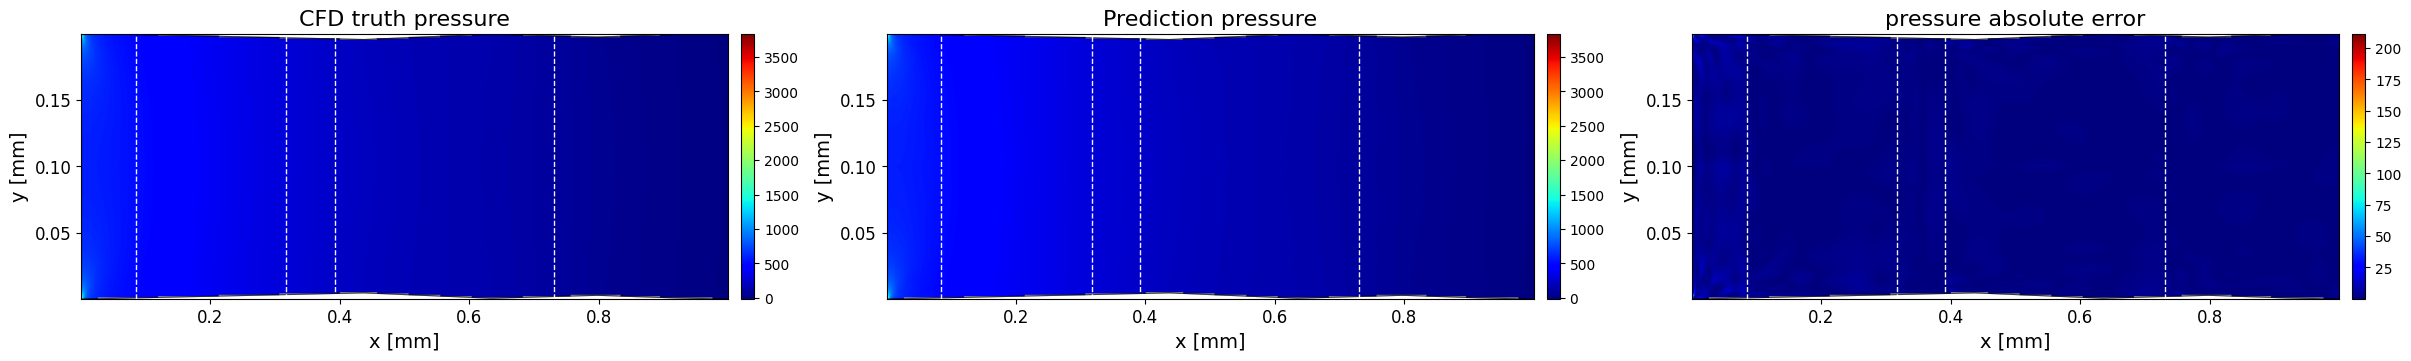

Saved: /home/hantianl/Documents/PIDIF/DeepONet/results/081826_1/predictions/validation/valid_case217_u.png


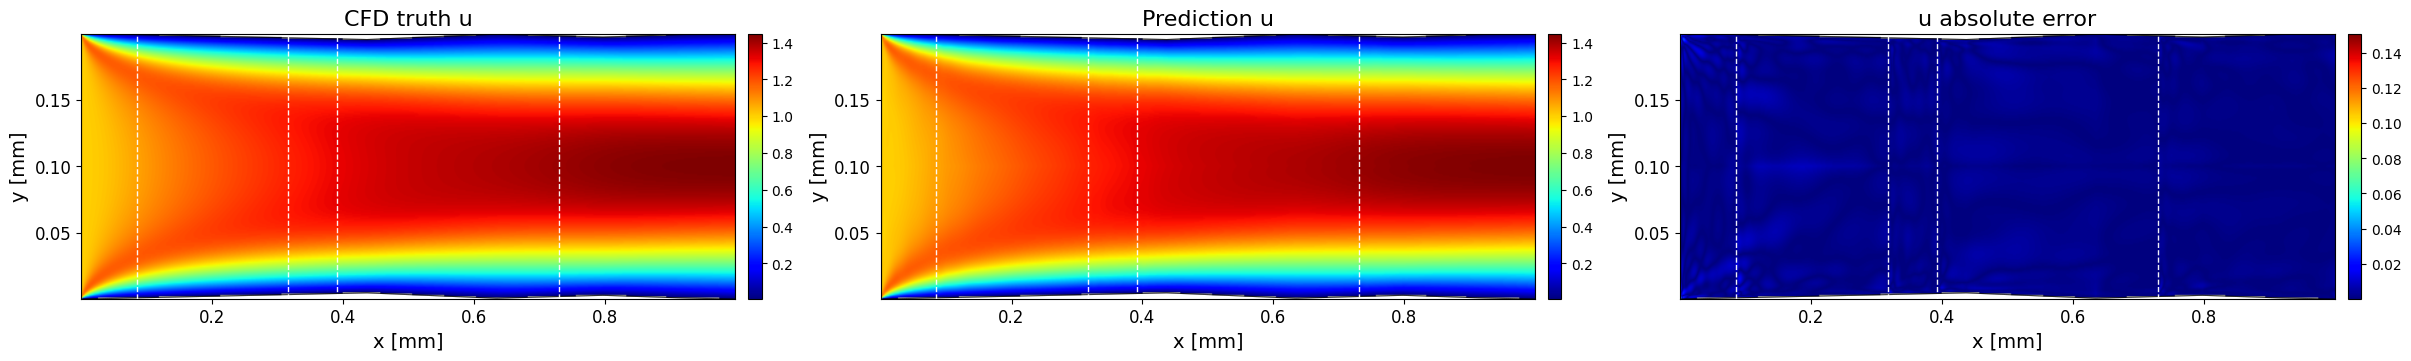

Saved: /home/hantianl/Documents/PIDIF/DeepONet/results/081826_1/predictions/validation/valid_case217_v.png


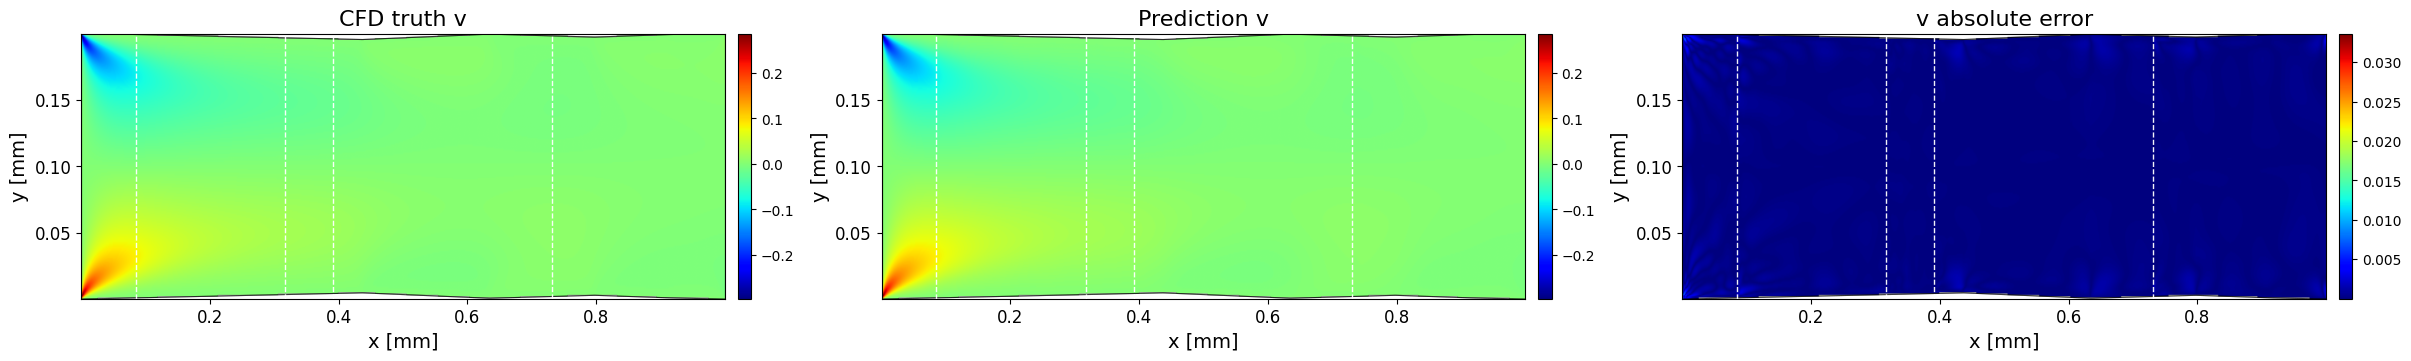

Total plotted points: 451268
x range: 0.00025669852 0.9997555
y range: -0.0034824933 0.20348866
Saved: /home/hantianl/Documents/PIDIF/DeepONet/results/081826_1/predictions/validation/valid_case257_pressure.png


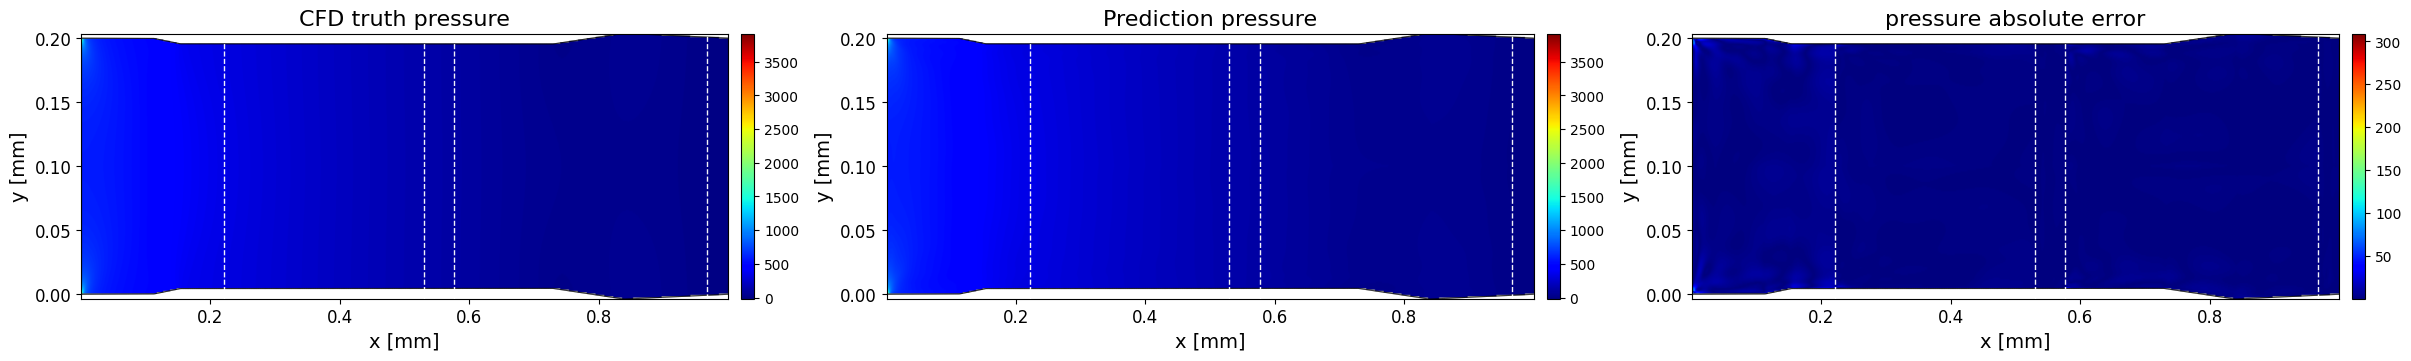

Saved: /home/hantianl/Documents/PIDIF/DeepONet/results/081826_1/predictions/validation/valid_case257_u.png


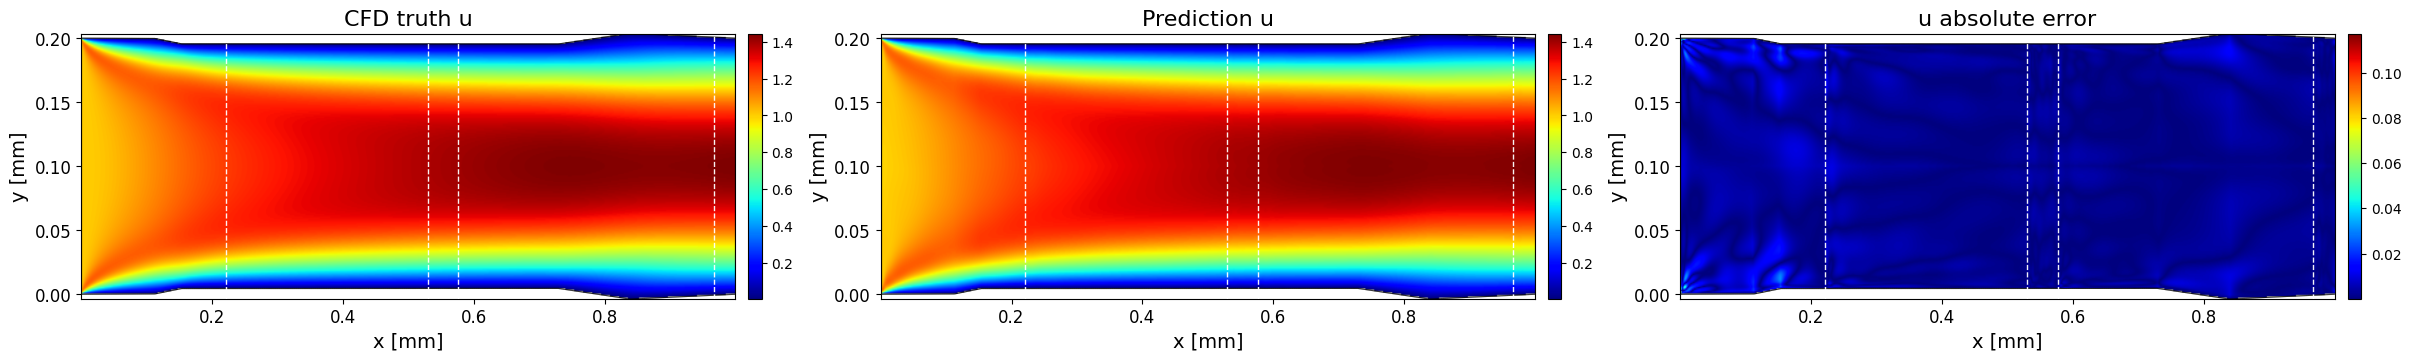

Saved: /home/hantianl/Documents/PIDIF/DeepONet/results/081826_1/predictions/validation/valid_case257_v.png


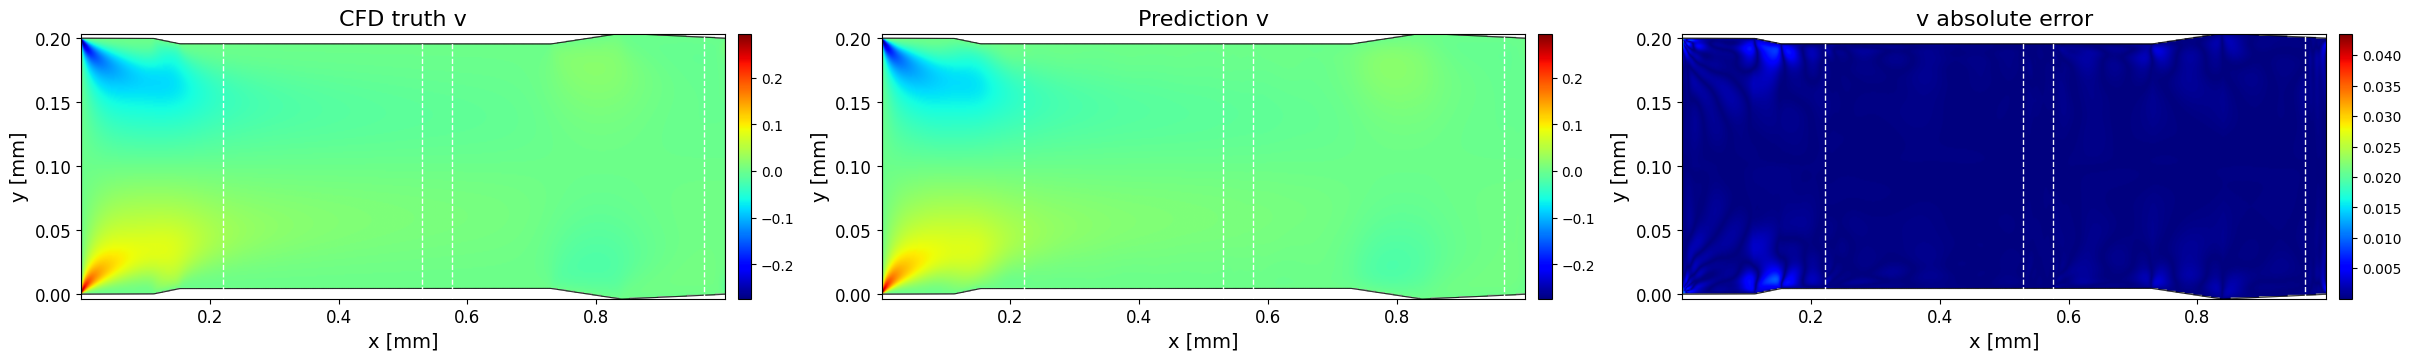

Total plotted points: 469228
x range: 0.00024169084 0.9997393
y range: -0.0041800635 0.20418096


In [ ]:
output_channel_names = list(valid_data["output_channel_names"])
    
for c in VALID_CASES:
    valid_case_sample_ids = sorted(
        (i for i, mm in enumerate(valid_data["metadata"]) if mm["case_id"] == c),
        key=lambda i: int(valid_data["metadata"][i]["subdomain_id"]),
    )
    metadata = valid_data["metadata"][valid_case_sample_ids[0]]

    plot_data = collect_predictions_for_data(
        model=model,
        data=valid_data,
        device=DEVICE,
        y_normalizer=y_normalizer,
        local_aspect_mean=local_aspect_mean,
        local_aspect_std=local_aspect_std,
        sample_indices=valid_case_sample_ids,
    )

    print("Total plotted points:", plot_data["x"].shape[0])
    print("x range:", plot_data["x"].min(), plot_data["x"].max())
    print("y range:", plot_data["y"].min(), plot_data["y"].max())

    for field_name in output_channel_names:
        field_idx = output_channel_names.index(field_name)

        plot_prediction_imshow_from_points(
            x=plot_data["x"],
            y=plot_data["y"],
            pred=plot_data["pred"],
            truth=plot_data["truth"],
            field_name=field_name,
            field_idx=field_idx,
            n_x_plot=2000,
            n_y_plot=200,
            metadata=plot_data["metadata"],
            metis_cut_face_midpoints=plot_data.get("metis_cut_face_midpoints"),
            interface_placement=plot_data.get("interface_placement"),
            mesh_h5=case_files[metadata["case_id"]]["mesh"],
            coord_unit="mm",
            output_dir=output_dir / "predictions" / "validation",
            filename_prefix=f"valid_case{int(c.split('_')[-1]):02d}",
        )

# Test sets: AR10 unseen shapes / AR8 interpolation / AR4 + AR20 extrapolation

In [ ]:
test_datas = {}
for set_name, set_cases in TEST_SETS.items():
    test_datas[set_name] = build_fluent_deeponet_dataset(
        case_files=case_files,
        case_ids=set_cases,
        n_subdomains="adaptive",
        n_interface_points=N_INTERFACE_POINTS,
        n_boundary_points=N_WALL_POINTS,
        interface_placement="fixed",
        interface_jitter=0,
        insert_sharp_control_point_interfaces=False,
        horizontal_interface=HORIZONTAL_INTERFACE,
        field_map=FIELD_MAP,
        bc_kwargs=bc_kwargs,
        keep_raw_case_data=False,
        rng=rng,
        include_reynolds=INCLUDE_REYNOLDS,
        include_sdf=INCLUDE_SDF,
        kinematic_viscosity=WATER_KINEMATIC_VISCOSITY,
    )
    print(f"[{set_name}] samples: {len(test_datas[set_name]['samples'])}")
output_channel_names = list(next(iter(test_datas.values()))["output_channel_names"])

In [ ]:
MAX_PLOT_CASES_PER_SET = 3  # keep the figure count sane; summaries cover all cases

set_summaries = {}
for set_name, test_data in test_datas.items():
    l2 = []
    case_rows = []
    set_cases = sorted({m["case_id"] for m in test_data["metadata"]},
                       key=lambda c: int(c.split("_")[-1]))
    for plot_i, c in enumerate(set_cases):
        sample_test_ids = sorted(
            (i for i, mm in enumerate(test_data["metadata"]) if mm["case_id"] == c),
            key=lambda i: int(test_data["metadata"][i]["subdomain_id"]),
        )
        if not sample_test_ids:
            continue

        plot_data = collect_predictions_for_data(
            model=model,
            data=test_data,
            device=DEVICE,
            y_normalizer=y_normalizer,
            local_aspect_mean=local_aspect_mean,
            local_aspect_std=local_aspect_std,
            sample_indices=sample_test_ids,
        )

        pred = plot_data["pred"]
        truth = plot_data["truth"]
        err = np.abs(pred - truth)
        rel_l2 = np.linalg.norm(err, axis=0) / np.maximum(np.linalg.norm(truth, axis=0), 1.0e-12)
        l2.append(rel_l2)
        case_rows.append({"case": c, **{f: float(v) for f, v in zip(output_channel_names, rel_l2)}})

        if plot_i < MAX_PLOT_CASES_PER_SET:
            for field_name in output_channel_names:
                plot_prediction_imshow_from_points(
                    x=plot_data["x"],
                    y=plot_data["y"],
                    pred=pred,
                    truth=truth,
                    field_name=field_name,
                    field_idx=output_channel_names.index(field_name),
                    metadata=plot_data["metadata"],
                    n_x_plot=2000,
                    n_y_plot=200,
                    coord_unit="mm",
                    output_dir=output_dir / "predictions" / f"test_{set_name}",
                    filename_prefix=f"test_case{int(c.split('_')[-1]):03d}",
                    mesh_h5=case_files[c]["mesh"],
                )

    l2 = np.asarray(l2)
    set_summaries[set_name] = {
        "n_cases": int(l2.shape[0]),
        "mean": l2.mean(axis=0),
        "max": l2.max(axis=0),
        "cases": case_rows,
    }
    print(f"[{set_name}] n={l2.shape[0]}")
    for f_i, f in enumerate(output_channel_names):
        print(f"  {f:9s} mean rel L2 = {l2[:, f_i].mean():.3e} | max = {l2[:, f_i].max():.3e}")

print("\n=== Summary (mean rel L2 per field) ===")
header = "set".ljust(14) + "".join(f"{f:>12s}" for f in output_channel_names)
print(header)
for set_name, s in set_summaries.items():
    print(set_name.ljust(14) + "".join(f"{v:12.3e}" for v in s["mean"]))

import csv as _csv
with open(output_dir / "test_set_summary.csv", "w", newline="") as f:
    w = _csv.writer(f)
    w.writerow(["set", "case"] + output_channel_names)
    for set_name, s in set_summaries.items():
        for row in s["cases"]:
            w.writerow([set_name, row["case"]] + [row[fld] for fld in output_channel_names])
print("Saved:", output_dir / "test_set_summary.csv")

# Extra test: legacy H=0.1mm shape pool (channels 000-019, 040-049)

In [ ]:
# Extra held-out shape-generalization pool: the legacy H = 0.1 mm ablation
# cases (000-019 and 040-049; ids 050-179 are the multi-AR groups after the
# 2026-08-18 renumbering and are managed by the main split / extrapolation sets).
ABLATION_DATASET = "channel_water_ablation"

def ablation_case_paths(ch):
    return {
        "design": ROOT_DIR / f"2d_geometry_specs/{ABLATION_DATASET}/{ch}.json",
        "mesh": ROOT_DIR / f"runs_2d/{ABLATION_DATASET}/{ch}/{ch}.msh.h5",
        "dat": ROOT_DIR / f"runs_2d/{ABLATION_DATASET}/{ch}/case2d.dat.h5",
    }

_ablation_pool = [f"channel_{i:03d}" for i in list(range(20)) + list(range(40, 50))]
ablation_cases = [
    ch for ch in _ablation_pool
    if all(ablation_case_paths(ch)[k].exists() for k in ("design", "mesh", "dat"))
]
ablation_case_files = {ch: ablation_case_paths(ch) for ch in ablation_cases}

print(f"Ablation cases ({len(ablation_cases)}):", ablation_cases)

In [ ]:
ABLATION_TEST_CASES = list(ablation_cases)

ablation_test_data = build_fluent_deeponet_dataset(
    case_files=ablation_case_files,
    case_ids=ABLATION_TEST_CASES,
    n_subdomains="adaptive",
    n_interface_points=N_INTERFACE_POINTS,
    n_boundary_points=N_WALL_POINTS,
    interface_placement="fixed",
    interface_jitter=0,
    insert_sharp_control_point_interfaces=False,
    horizontal_interface=HORIZONTAL_INTERFACE,
    field_map=FIELD_MAP,
    bc_kwargs=bc_kwargs,
    keep_raw_case_data=False,
    rng=rng,
    include_reynolds=INCLUDE_REYNOLDS,
    include_sdf=INCLUDE_SDF,
    kinematic_viscosity=WATER_KINEMATIC_VISCOSITY,
)
output_channel_names = ablation_test_data["output_channel_names"]
print("Ablation test samples:", len(ablation_test_data["samples"]))
print("Ablation test cases:", sorted({m["case_id"] for m in ablation_test_data["metadata"]}))

In [ ]:
l2 = []
for c in ABLATION_TEST_CASES:
    sample_test_ids = sorted(
        (i for i, mm in enumerate(ablation_test_data["metadata"]) if mm["case_id"] == c),
        key=lambda i: int(ablation_test_data["metadata"][i]["subdomain_id"]),
    )
    if not sample_test_ids:
        continue
    metadata = ablation_test_data["metadata"][sample_test_ids[0]]
    

    plot_data = collect_predictions_for_data(
        model=model,
        data=ablation_test_data,
        device=DEVICE,
        y_normalizer=y_normalizer,
        local_aspect_mean=local_aspect_mean,
        local_aspect_std=local_aspect_std,
        sample_indices=sample_test_ids,
    )

    print("Total plotted points:", plot_data["x"].shape[0])
    print("x range:", plot_data["x"].min(), plot_data["x"].max())
    print("y range:", plot_data["y"].min(), plot_data["y"].max())
    
    pred = plot_data["pred"]
    truth = plot_data["truth"]
    err = np.abs(pred - truth)
    rel_l2 = np.linalg.norm(err, axis=0) / np.maximum(np.linalg.norm(truth, axis=0), 1.0e-12)
    l2.append(rel_l2)
    overall_avg_rel_l2 = float(np.mean(rel_l2))
    max_field_err = err.max(axis=0)
    print(f"Test case {c} rel l2: {rel_l2}")
    print(f"Test case {c} overall avg rel L2: {overall_avg_rel_l2:.3e}")
    print(f"Test case {c} max field err: {max_field_err}")

    for field_name in output_channel_names:
        field_idx = output_channel_names.index(field_name)

        plot_prediction_imshow_from_points(
            x=plot_data["x"],
            y=plot_data["y"],
            pred=plot_data["pred"],
            truth=plot_data["truth"],
            field_name=field_name,
            field_idx=field_idx,
            metadata=plot_data["metadata"],
            # metis_cut_face_midpoints=plot_data.get("metis_cut_face_midpoints"),
            # interface_placement=plot_data.get("interface_placement"),
            n_x_plot=2000,
            n_y_plot=200,
            coord_unit="mm",
            output_dir=output_dir / "predictions" / "test_ablation",
            filename_prefix=f"test_case{int(c.split('_')[-1]):02d}",
            mesh_h5=ablation_case_files[ablation_test_data["metadata"][sample_test_ids[0]]["case_id"]]["mesh"],
        )

l2 = np.array(l2)
l2_err = np.mean(l2, axis=0)
l2_err_max = np.max(l2, axis=0)
l2_err_min = np.min(l2, axis=0)

print(l2_err)
print(l2_err_max)